In [ ]:
# 查看当前挂载的数据集目录, 该目录下的变更重启环境后会自动还原
# View dataset directory. 
# This directory will be recovered automatically after resetting environment. 
!ls /home/aistudio/data

In [ ]:
# 查看工作区文件，该目录下除data目录外的变更将会持久保存。请及时清理不必要的文件，避免加载过慢。
# View personal work directory. 
# All changes, except /data, under this directory will be kept even after reset. 
# Please clean unnecessary files in time to speed up environment loading. 
!ls /home/aistudio

In [ ]:
# 如果需要进行持久化安装, 需要使用持久化路径, 如下方代码示例:
# If a persistence installation is required, 
# you need to use the persistence path as the following: 
!mkdir /home/aistudio/external-libraries
!pip install beautifulsoup4

In [ ]:
# 同时添加如下代码, 这样每次环境(kernel)启动的时候只要运行下方代码即可: 
# Also add the following code, 
# so that every time the environment (kernel) starts, 
# just run the following code: 
import sys 
sys.path.append('/home/aistudio/external-libraries')

请点击[此处](https://ai.baidu.com/docs#/AIStudio_Project_Notebook/a38e5576)查看本环境基本用法.  <br>
Please click [here ](https://ai.baidu.com/docs#/AIStudio_Project_Notebook/a38e5576) for more detailed instructions. 

In [ ]:
import pandas as pd
import glob
import os

# 1. 获取 data 文件夹下所有的 csv 文件路径
path = './data' 
all_files = glob.glob(os.path.join(path, "*.csv"))

# 2. 批量读取并合并
li = []
for filename in all_files:
    df = pd.read_csv(filename, index_col=None, header=0)
    # 增加一列记录井名，方便后续分析
    df['WELL_NAME'] = os.path.basename(filename)
    li.append(df)

full_df = pd.concat(li, axis=0, ignore_index=True)

# 3. 观察数据的前几行和基本信息
print("合并后的数据集行列数：", full_df.shape)
print("-" * 30)
print("各列的缺失值情况：")
print(full_df.isnull().sum())
print("-" * 30)
print("前 5 行预览：")
display(full_df.head())

合并后的数据集行列数： (81308, 30)
------------------------------
各列的缺失值情况：
WELL                                     0
DEPTH_MD                                 0
X_LOC                                    0
Y_LOC                                    0
Z_LOC                                    0
GROUP                                    0
FORMATION                             3503
CALI                                     4
RSHA                                 60911
RMED                                  6468
RDEP                                     0
RHOB                                  5758
GR                                       0
SGR                                  80169
NPHI                                 11066
PEF                                  21698
DTC                                    279
SP                                   41614
BS                                   37552
ROP                                    108
DTS                                  43980
DCAL                            

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE,WELL_NAME
0,17/4-1,1147.550793,515574.4375,6495507.0,-1120.550781,ROGALAND GP.,Lista Fm.,17.488379,NaN,0.861654,...,NaN,NaN,-0.247000,NaN,NaN,NaN,NaN,65000.0,1.0,17_4-1.csv
1,17/4-1,1147.702793,515574.4375,6495507.0,-1120.702759,ROGALAND GP.,Lista Fm.,17.501503,NaN,0.865444,...,NaN,NaN,-0.247000,NaN,NaN,NaN,NaN,65000.0,1.0,17_4-1.csv
2,17/4-1,1147.854793,515574.4375,6495507.0,-1120.854736,ROGALAND GP.,Lista Fm.,17.511805,NaN,0.867254,...,NaN,NaN,-0.246284,NaN,NaN,NaN,NaN,65000.0,1.0,17_4-1.csv
3,17/4-1,1148.006793,515574.4375,6495507.0,-1121.006836,ROGALAND GP.,Lista Fm.,17.492559,NaN,0.867034,...,NaN,NaN,-0.246000,NaN,NaN,NaN,NaN,65000.0,1.0,17_4-1.csv
4,17/4-1,1148.158793,515574.4375,6495507.0,-1121.158813,ROGALAND GP.,Lista Fm.,17.466230,NaN,0.864944,...,NaN,NaN,-0.246000,NaN,NaN,NaN,NaN,65000.0,1.0,17_4-1.csv


In [ ]:
!pip install scikit-learn

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. 剔除缺失标签
full_df = full_df.dropna(subset=['FORCE_2020_LITHOFACIES_LITHOLOGY'])

# 2. 特征选择
selected_features = ['GR', 'RDEP', 'RHOB', 'NPHI', 'DTC']
target_col = 'FORCE_2020_LITHOFACIES_LITHOLOGY'

# 3. 提取特征和标签并显式创建 data 变量
data = full_df[selected_features + [target_col, 'WELL_NAME']].copy()

# 4. 数据清洗
data[selected_features] = data[selected_features].ffill().bfill()

# 5. 【关键】生成 label 列
le = LabelEncoder()
data['label'] = le.fit_transform(data[target_col])
num_classes = len(le.classes_)

# 6. 标准化
scaler = StandardScaler()
data[selected_features] = scaler.fit_transform(data[selected_features])

print(f"预处理成功！当前分类总数: {num_classes}")
print(f"确认列名包含 label: {'label' in data.columns}")

Looking in indexes: http://mirrors.baidubce.com/pypi/simple/
预处理成功！当前分类总数: 11
确认列名包含 label: True


In [ ]:
import numpy as np

seq_length = 50 

def create_sequences(df, features, seq_len):
    xs = []
    ys = []
    for well in df['WELL_NAME'].unique():
        well_data = df[df['WELL_NAME'] == well]
        if len(well_data) < seq_len: continue # 跳过数据量太少的井
        
        feature_data = well_data[features].values
        label_data = well_data['label'].values # 现在这里不会报错了
        
        for i in range(len(well_data) - seq_len):
            x = feature_data[i:(i + seq_len)]
            y = label_data[i + seq_len]
            xs.append(x)
            ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(data, selected_features, seq_length)

# 划分数据集
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"训练集形状: {X_train.shape}")

训练集形状: (48621, 50, 5)


In [ ]:
import paddle

# 1. 将 NumPy 数组转换为 Paddle Tensor
# X_train 的形状是 (48621, 50, 5)
X_train_tensor = paddle.to_tensor(X_train.astype('float32'))
y_train_tensor = paddle.to_tensor(y_train.astype('int64'))

# 同时也把测试集转换好，备后用
X_test_tensor = paddle.to_tensor(X_test.astype('float32'))
y_test_tensor = paddle.to_tensor(y_test.astype('int64'))

print("Tensor 转换完成！")
print(f"训练张量形状: {X_train_tensor.shape}")

Tensor 转换完成！
训练张量形状: paddle.Size([48621, 50, 5])


In [ ]:
import paddle
import paddle.nn as nn

# 【核心步骤】定义双向 LSTM 模型类
# 这部分内容可以作为你报告 2.5.2 章节的图表说明
class BiLSTMModel(nn.Layer):
    def __init__(self, input_size, hidden_size, num_classes):
        super(BiLSTMModel, self).__init__()
        # direction='bidirectional' 表示双向，这在处理测井这种具有深度连续性的数据时非常有效
        self.lstm = nn.LSTM(input_size, hidden_size, direction='bidirectional', num_layers=2)
        # 这里的 hidden_size * 2 是因为双向拼接了特征
        self.fc = nn.Linear(hidden_size * 2, num_classes)
        
    def forward(self, x):
        # x 的形状: [batch_size, seq_len, input_size]
        out, (h, c) = self.lstm(x)
        # 取序列的最后一个时间步进行分类预测
        out = self.fc(out[:, -1, :])
        return out

# 1. 设置模型参数
input_size = 5    # 我们选取的 GR, RDEP, RHOB, NPHI, DTC
hidden_size = 64  # 隐含层神经元数量
# num_classes 是之前 LabelEncoder 得到的类别数

# 2. 实例化模型
model = BiLSTMModel(input_size=input_size, hidden_size=hidden_size, num_classes=num_classes)

# 3. 定义损失函数和优化器 (对应报告 2.5.3)
criterion = nn.CrossEntropyLoss()
optimizer = paddle.optimizer.Adam(learning_rate=0.001, parameters=model.parameters())

print("BiLSTM 模型定义并实例化成功！")

BiLSTM 模型定义并实例化成功！


开始正式训练...
Epoch [2/20], Loss: 0.4463
Epoch [4/20], Loss: 0.3445
Epoch [6/20], Loss: 0.3024
Epoch [8/20], Loss: 0.2975
Epoch [10/20], Loss: 0.2423
Epoch [12/20], Loss: 0.2131
Epoch [14/20], Loss: 0.1963
Epoch [16/20], Loss: 0.1901
Epoch [18/20], Loss: 0.1778
Epoch [20/20], Loss: 0.1632
训练完成！总耗时: 821.38秒


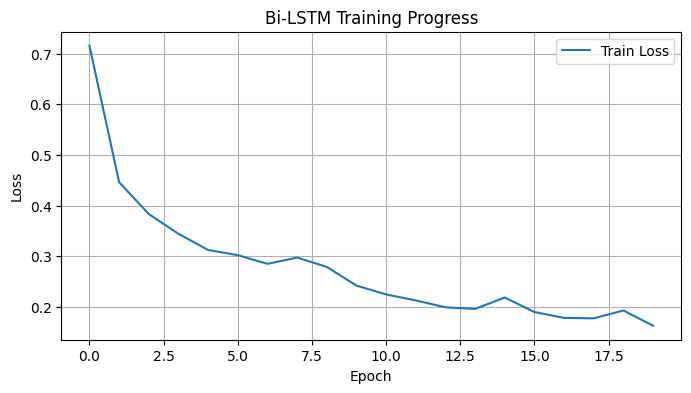


>>> 测试集最终准确率: 67.13% <<<


In [ ]:
import time
import matplotlib.pyplot as plt

# 1. 再次确认数据加载器
train_loader = paddle.io.DataLoader(train_dataset, batch_size=128, shuffle=True)

history_loss = []
epochs = 20
start_time = time.time()

print("开始正式训练...")
model.train()
for epoch in range(epochs):
    epoch_loss = 0
    batch_count = 0
    
    for batch_id, data in enumerate(train_loader()):
        x_batch, y_batch = data
        
        # 前向传播
        predicts = model(x_batch)
        loss = criterion(predicts, y_batch)
        
        # 反向传播
        loss.backward()
        optimizer.step()
        optimizer.clear_grad()
        
        # 【此处已修复】使用 float(loss) 获取标量值
        epoch_loss += float(loss)
        batch_count += 1
        
    avg_loss = epoch_loss / batch_count
    history_loss.append(avg_loss)
    
    if (epoch + 1) % 2 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

print(f"训练完成！总耗时: {time.time() - start_time:.2f}秒")

# 2. 绘制 Loss 曲线 (截图保存，放入报告 2.6)
plt.figure(figsize=(8, 4))
plt.plot(history_loss, label='Train Loss')
plt.title('Bi-LSTM Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 3. 立即验证准确率 (对应任务目标)
model.eval()
with paddle.no_grad():
    logits = model(X_test_tensor)
    preds = paddle.argmax(logits, axis=1).numpy()
    actuals = y_test_tensor.numpy()
    accuracy = (preds == actuals).mean()
    print(f"\n>>> 测试集最终准确率: {accuracy * 100:.2f}% <<<")

In [ ]:
model.eval()
with paddle.no_grad():
    # 预测测试集
    logits = model(X_test_tensor)
    preds = paddle.argmax(logits, axis=1).numpy()
    actuals = y_test_tensor.numpy()

# 计算总准确率
accuracy = (preds == actuals).mean()
print(f"★ 测试集最终准确率: {accuracy * 100:.2f}%")

★ 测试集最终准确率: 67.13%


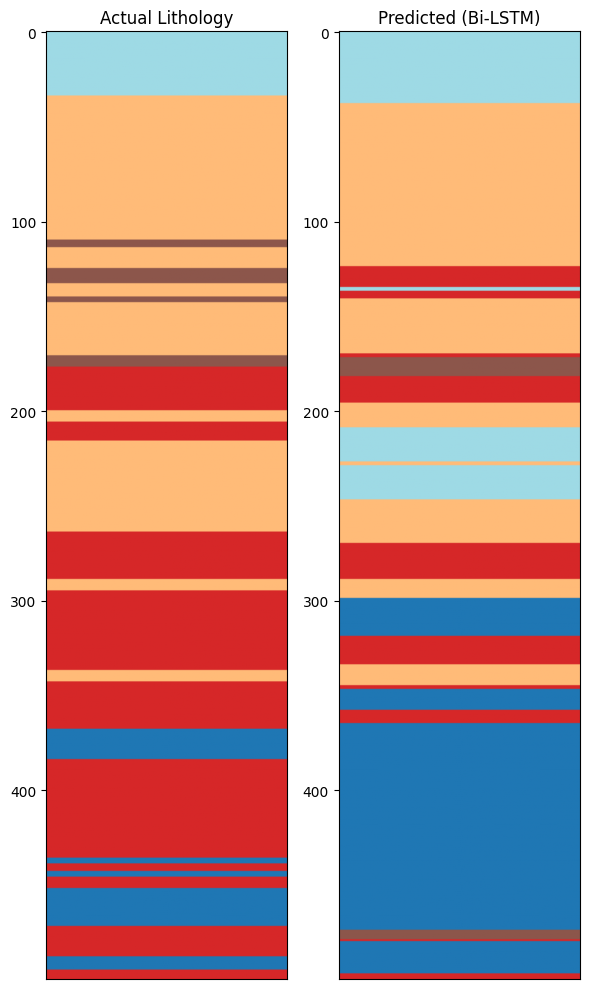

In [35]:
def plot_lithology_comparison(actual, predicted, num_points=500):
    plt.figure(figsize=(6, 10))
    
    # 1. 真实岩性柱
    plt.subplot(1, 2, 1)
    plt.imshow(actual[:num_points].reshape(-1, 1), aspect='auto', cmap='tab20')
    plt.title('Actual Lithology')
    plt.xticks([])
    
    # 2. 预测岩性柱
    plt.subplot(1, 2, 2)
    plt.imshow(predicted[:num_points].reshape(-1, 1), aspect='auto', cmap='tab20')
    plt.title('Predicted (Bi-LSTM)')
    plt.xticks([])
    
    plt.tight_layout()
    plt.show()

# 调用函数，查看前 500 个深度点的识别效果
plot_lithology_comparison(actuals, preds)


>>> 正在启动实验：Uni-Directional LSTM ...
  Uni-Directional LSTM - Epoch [1/10], Loss: 0.6722
  Uni-Directional LSTM - Epoch [2/10], Loss: 0.4734
  Uni-Directional LSTM - Epoch [3/10], Loss: 0.1885
  Uni-Directional LSTM - Epoch [4/10], Loss: 0.5106
  Uni-Directional LSTM - Epoch [5/10], Loss: 0.3707
  Uni-Directional LSTM - Epoch [6/10], Loss: 0.3182
  Uni-Directional LSTM - Epoch [7/10], Loss: 0.2494
  Uni-Directional LSTM - Epoch [8/10], Loss: 0.2067
  Uni-Directional LSTM - Epoch [9/10], Loss: 0.2406
  Uni-Directional LSTM - Epoch [10/10], Loss: 0.1880
>>> Uni-Directional LSTM 训练完成！准确率: 69.64% | 耗时: 154.26s

>>> 正在启动实验：Bi-Directional LSTM ...
  Bi-Directional LSTM - Epoch [1/10], Loss: 0.3422
  Bi-Directional LSTM - Epoch [2/10], Loss: 0.4372
  Bi-Directional LSTM - Epoch [3/10], Loss: 0.3255
  Bi-Directional LSTM - Epoch [4/10], Loss: 0.3335
  Bi-Directional LSTM - Epoch [5/10], Loss: 0.2633
  Bi-Directional LSTM - Epoch [6/10], Loss: 0.2579
  Bi-Directional LSTM - Epoch [7/10], Loss: 

,实验项,测试集准确率 (%),训练耗时 (s),最终 Loss
0,单向 LSTM (Baseline),69.64%,154.26,0.1880
1,双向 LSTM (Bi-LSTM),69.39%,407.46,0.3659


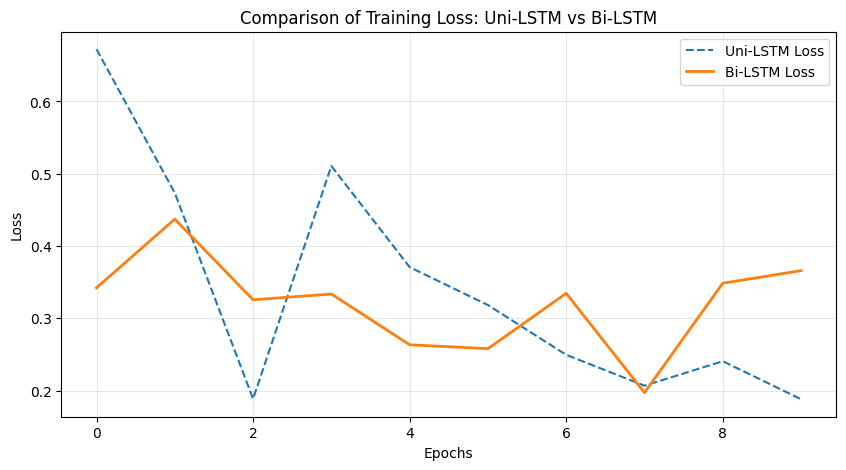

In [37]:
import paddle
import paddle.nn as nn
import time
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. 定义通用模型类 (支持单向和双向) ---
class LSTMComparator(nn.Layer):
    def __init__(self, input_size, hidden_size, num_classes, bidirectional=True):
        super(LSTMComparator, self).__init__()
        direction = 'bidirectional' if bidirectional else 'forward'
        self.lstm = nn.LSTM(input_size, hidden_size, direction=direction, num_layers=2)
        # 如果是双向，全连接层输入是 hidden_size * 2
        self.multiplier = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_size * self.multiplier, num_classes)
        
    def forward(self, x):
        out, (h, c) = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# --- 2. 核心训练函数 ---
def run_experiment(is_bidi, name):
    print(f"\n>>> 正在启动实验：{name} ...")
    
    # 实例化模型
    exp_model = LSTMComparator(input_size=5, hidden_size=64, num_classes=num_classes, bidirectional=is_bidi)
    criterion = nn.CrossEntropyLoss()
    optimizer = paddle.optimizer.Adam(learning_rate=0.001, parameters=exp_model.parameters())
    
    # 准备数据
    train_loader = paddle.io.DataLoader(train_dataset, batch_size=128, shuffle=True)
    
    history_loss = []
    start_t = time.time()
    
    # 训练循环 (为了速度，对比实验设为 10 轮即可看出差异)
    exp_model.train()
    for epoch in range(10):
        for batch_id, data in enumerate(train_loader()):
            x_batch, y_batch = data
            predicts = exp_model(x_batch)
            loss = criterion(predicts, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.clear_grad()
        
        avg_l = float(loss)
        history_loss.append(avg_l)
        print(f"  {name} - Epoch [{epoch+1}/10], Loss: {avg_l:.4f}")
    
    duration = time.time() - start_t
    
    # 评估准确率
    exp_model.eval()
    with paddle.no_grad():
        logits = exp_model(X_test_tensor)
        preds = paddle.argmax(logits, axis=1).numpy()
        acc = (preds == y_test_tensor.numpy()).mean()
        
    print(f">>> {name} 训练完成！准确率: {acc*100:.2f}% | 耗时: {duration:.2f}s")
    return acc, history_loss, duration

# --- 3. 执行对比 ---
# 实验 A：单向 LSTM
acc_uni, loss_uni, time_uni = run_experiment(is_bidi=False, name="Uni-Directional LSTM")

# 实验 B：双向 LSTM (Bi-LSTM)
acc_bi, loss_bi, time_bi = run_experiment(is_bidi=True, name="Bi-Directional LSTM")

# --- 4. 自动生成对比结果表格 ---
results = pd.DataFrame({
    "实验项": ["单向 LSTM (Baseline)", "双向 LSTM (Bi-LSTM)"],
    "测试集准确率 (%)": [f"{acc_uni*100:.2f}%", f"{acc_bi*100:.2f}%"],
    "训练耗时 (s)": [f"{time_uni:.2f}", f"{time_bi:.2f}"],
    "最终 Loss": [f"{loss_uni[-1]:.4f}", f"{loss_bi[-1]:.4f}"]
})

print("\n" + "="*30)
print("对比实验结果汇总 (直接复制到报告)")
print("="*30)
display(results)

# --- 5. 绘制对比 Loss 曲线 ---
plt.figure(figsize=(10, 5))
plt.plot(loss_uni, label='Uni-LSTM Loss', linestyle='--')
plt.plot(loss_bi, label='Bi-LSTM Loss', linewidth=2)
plt.title('Comparison of Training Loss: Uni-LSTM vs Bi-LSTM')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()